# RAG-Collapse · HotpotQA diverse-distractor sweep — results

Plots for the `diverse_synth` round-0 distractor experiment (oz03-hub setup): **qwen2.5-14b** answerer +
**qwen2.5-7b-docgen** per-round doc synthesis + **gpt-5-mini** round-0 distractors, native 2-gold/8-distractor
context, gold never corrupted. Sweep over 3 variants × fractions {0, 0.3, 0.5, 0.7}, 3 rounds, 7-question
eligible cohort, seed 42.

Each chart is its own figure (light theme), saved to `visualization_outputs/oz03_distractor_figures/`.
The **per-round dynamics** show every fraction (one line per fraction) for each variant; the
**dose-response** charts show the final round across fractions. Data lives in `oz03_distractor_sweep/`
(gitignored): `scp -r unity:~/oz03_distractor_sweep <repo>/oz03_distractor_sweep`.

> Caveat: 7-question cohort — directional, not statistically significant. See `docs/hotpotqa_diverse_synth.html` §11.

In [1]:
import json, pathlib
import matplotlib.pyplot as plt

DATA = pathlib.Path("oz03_distractor_sweep")
FIGDIR = pathlib.Path("visualization_outputs/oz03_distractor_figures"); FIGDIR.mkdir(parents=True, exist_ok=True)
VARIANTS = ["search", "hybrid", "replace_one"]
VLABEL = {"search": "search (growing store)", "hybrid": "hybrid / replace-all", "replace_one": "replace_one"}
FRACS = ["0", "0.3", "0.5", "0.7"]; ROUNDS = [0, 1, 2]

INK, MUTE, GRID, EDGE = "#1f2430", "#5b6472", "#e4e7ee", "#c6ccd8"
FC = {"0": "#000000", "0.3": "#2563eb", "0.5": "#d97706", "0.7": "#7c3aed"}  # black/blue/amber/violet
VC = {"search": "#7c3aed", "hybrid": "#0d9488", "replace_one": "#b45309"}
REF = "#dc2626"
MSHORT = {"gold_match": "gold", "distractor_adoption": "adopt", "distinct_answers": "distinct"}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "savefig.bbox": "tight", "savefig.dpi": 120, "figure.dpi": 120,
    "text.color": INK, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.edgecolor": EDGE, "xtick.color": MUTE, "ytick.color": MUTE,
    "grid.color": GRID, "axes.grid": True, "grid.alpha": 1.0, "font.size": 12,
    "axes.titlesize": 13.5, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2.4, "lines.markersize": 7,
})
summ = {v: json.loads((DATA / f"sweep_summary_{v}.json").read_text())["fractions"] for v in VARIANTS}
def ser(v, f, m): return [summ[v][f][str(r)][m] for r in ROUNDS]
xf = [float(f) for f in FRACS]

def dyn_metric(metric, title, ylabel, ref1=False, ymax=None):
    """One figure PER VARIANT; lines = all fractions over rounds."""
    for v in VARIANTS:
        fig, ax = plt.subplots(figsize=(7.4, 4.8))
        for f in FRACS:
            ax.plot(ROUNDS, ser(v, f, metric), marker="o", color=FC[f], label=f"f = {f}")
        if ref1:
            ax.axhline(1.0, color=REF, ls=":", lw=1.3)
            ax.text(2, 1.03, "full collapse", color=REF, fontsize=9, ha="right", va="bottom")
        ax.set_title(f"{title} — {VLABEL[v]}")
        ax.set_xlabel("round"); ax.set_ylabel(ylabel); ax.set_xticks(ROUNDS)
        ax.set_ylim(0.8 if ref1 else -0.02, ymax)
        ax.legend(title="fraction", ncol=2, fontsize=9, title_fontsize=9)
        fig.tight_layout(); fig.savefig(FIGDIR / f"dyn_{MSHORT[metric]}_{v}.png"); plt.show()

def dose(metric, title, ylabel, ref1=False, ymax=None, fname=None):
    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    for v in VARIANTS:
        ax.plot(xf, [summ[v][f]["2"][metric] for f in FRACS], marker="o", color=VC[v], label=VLABEL[v])
    if ref1:
        ax.axhline(1.0, color=REF, ls=":", lw=1.3); ax.text(0.7, 1.03, "full collapse", color=REF, fontsize=9, ha="right", va="bottom")
    ax.set_title(title); ax.set_xlabel("distractor fraction"); ax.set_ylabel(ylabel); ax.set_xticks(xf)
    ax.set_ylim(0.8 if ref1 else -0.02, ymax); ax.legend()
    fig.tight_layout(); fig.savefig(FIGDIR / fname); plt.show()

print("loaded", list(summ), "| figures ->", FIGDIR)

loaded ['search', 'hybrid', 'replace_one'] | figures -> visualization_outputs\oz03_distractor_figures


## 1 · Per-round dynamics — gold match (all fractions)

One chart per variant; each line is a distractor fraction. f=0 is the clean baseline.

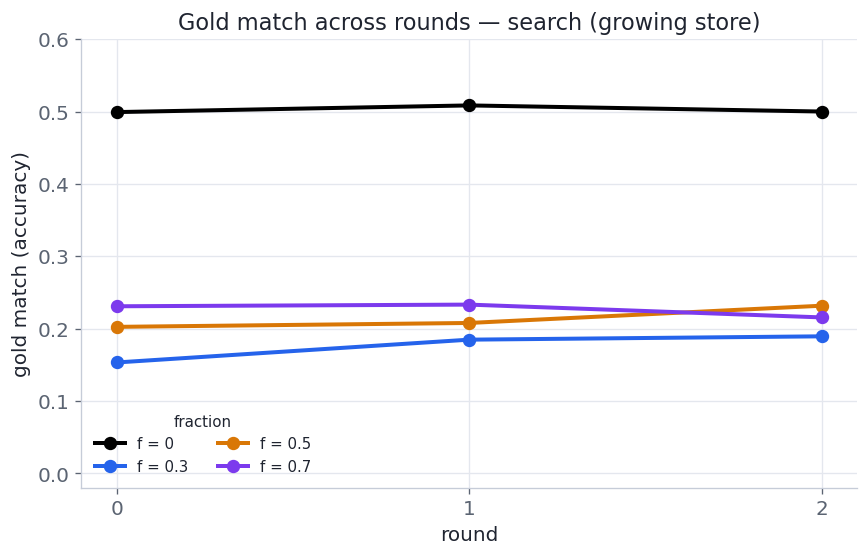

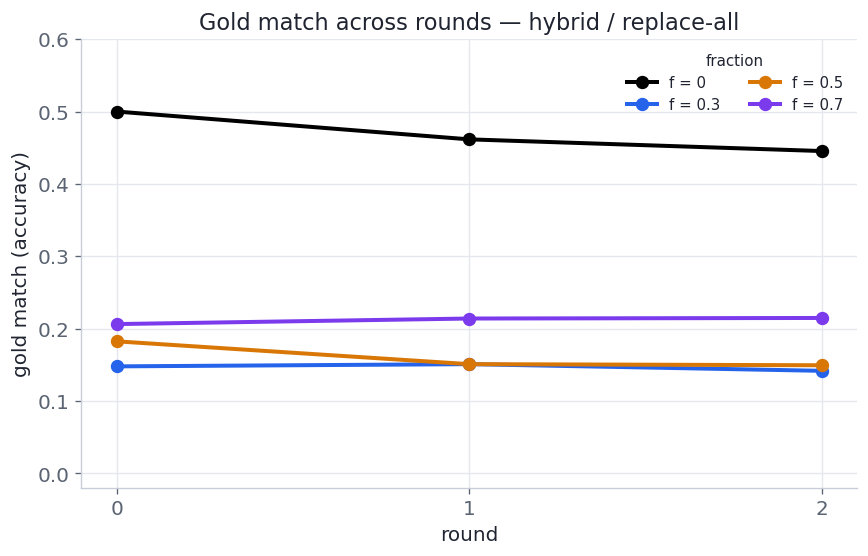

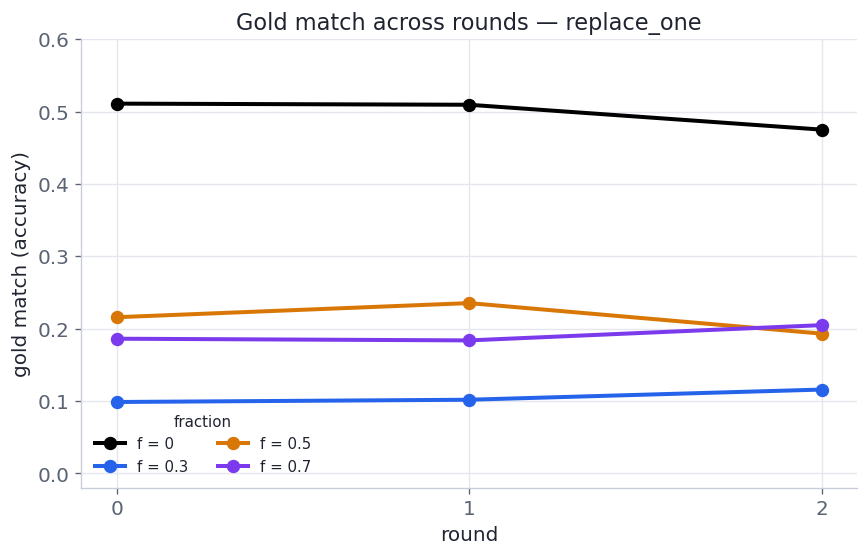

In [2]:
dyn_metric("gold_match", "Gold match across rounds", "gold match (accuracy)", ymax=0.6)

## 2 · Per-round dynamics — distractor adoption (all fractions)

`search` sustains adoption (distractors persist); `hybrid` decays (context overwritten); `replace_one` in between.

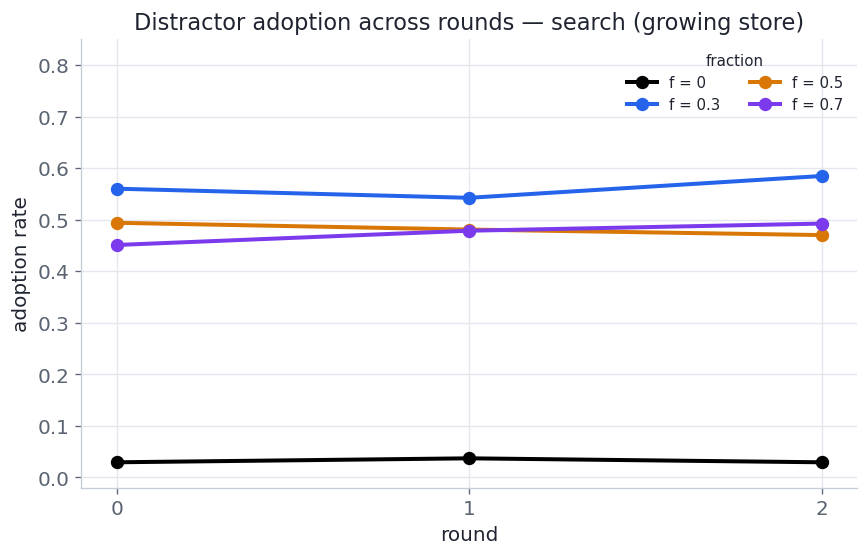

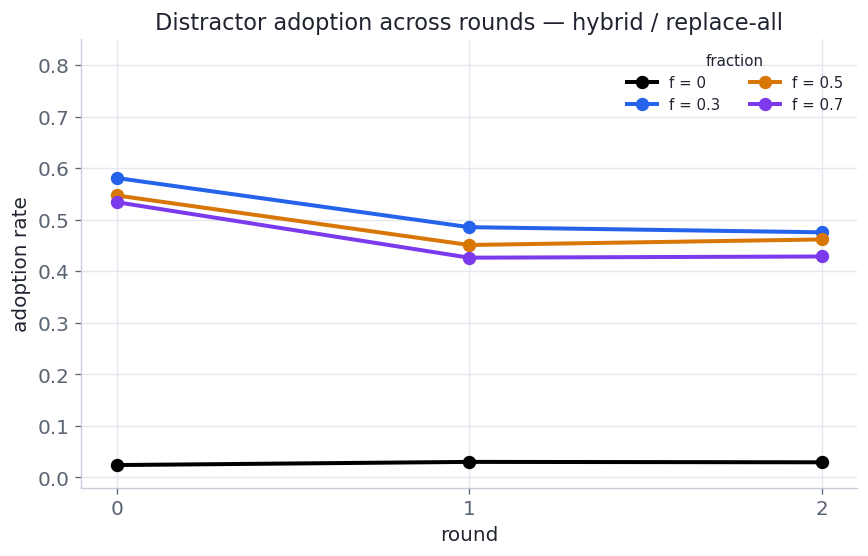

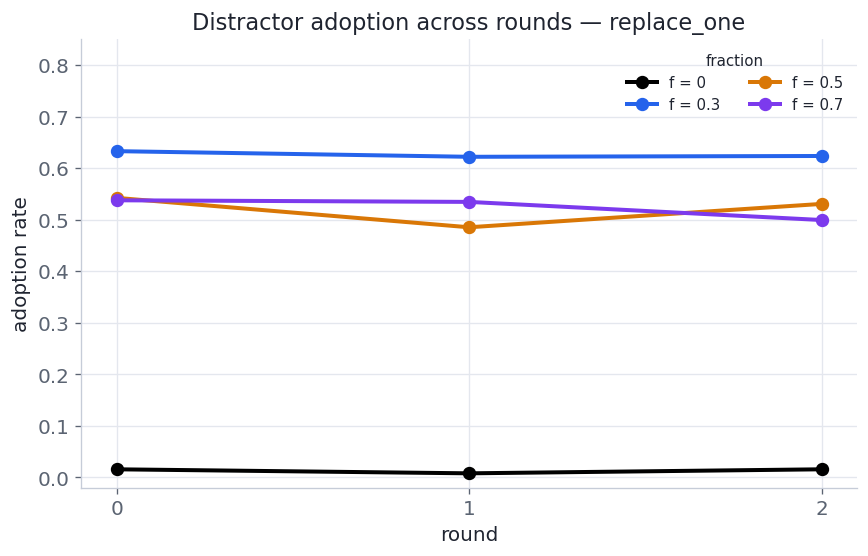

In [3]:
dyn_metric("distractor_adoption", "Distractor adoption across rounds", "adoption rate", ymax=0.85)

## 3 · Per-round dynamics — distinct answers (all fractions)

The dotted line at 1.0 is full collapse (every run of a question agrees).

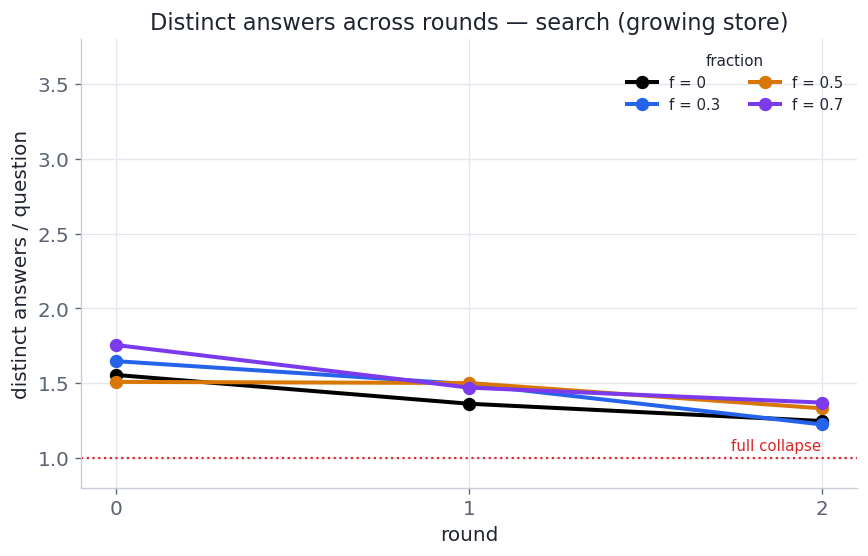

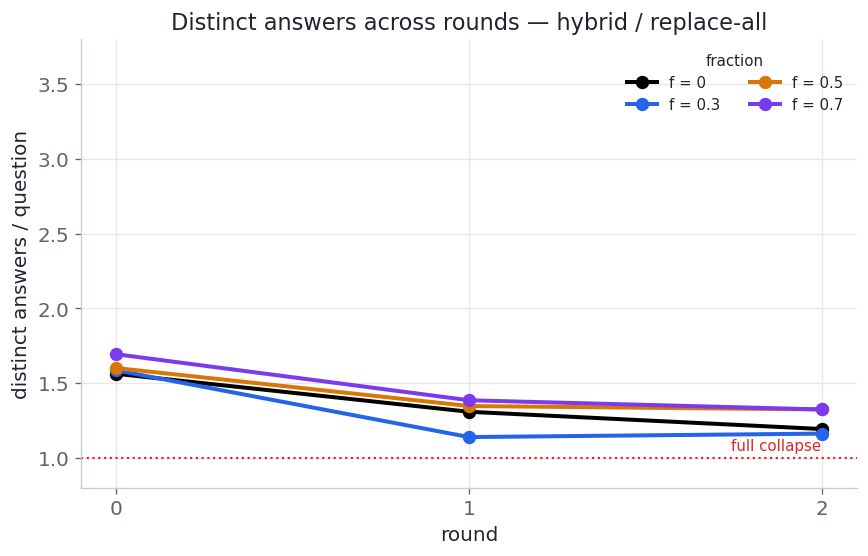

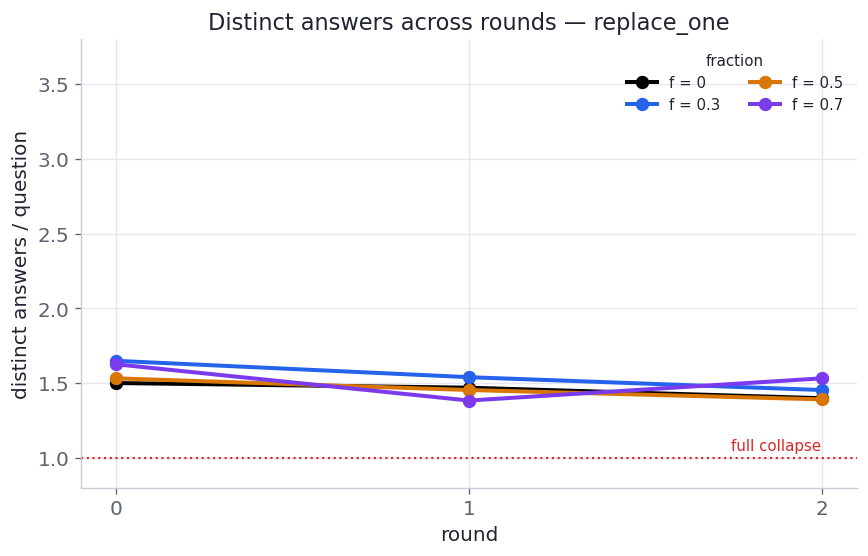

In [4]:
dyn_metric("distinct_answers", "Distinct answers across rounds", "distinct answers / question", ref1=True, ymax=3.8)

## 4 · Dose-response (final round, r2)

How the final state depends on the distractor fraction; lines are variants.

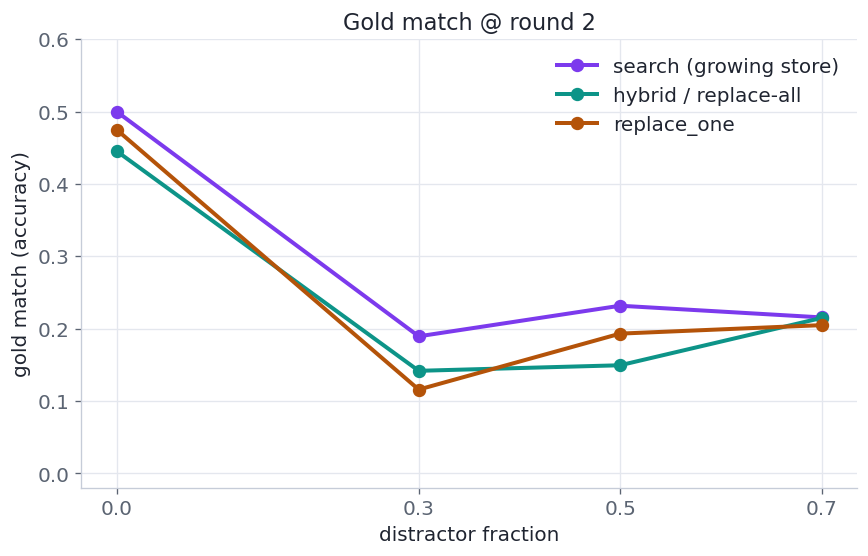

In [5]:
dose("gold_match", "Gold match @ round 2", "gold match (accuracy)", ymax=0.6, fname="dose_gold_match.png")

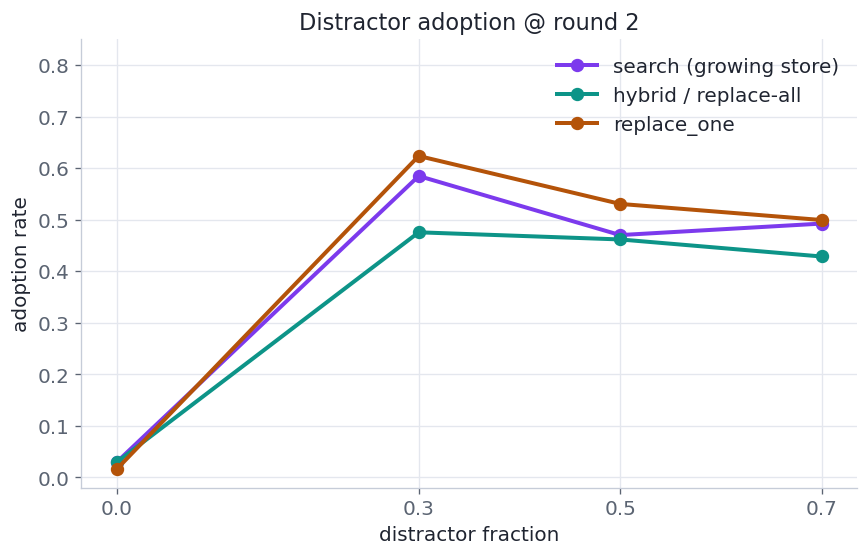

In [6]:
dose("distractor_adoption", "Distractor adoption @ round 2", "adoption rate", ymax=0.85, fname="dose_adoption.png")

## 5 · Concentration vs diffusion

Final-round `distinct_answers` vs fraction: `search` hugs 1.0 (lock-in); the others rise (diffusion).

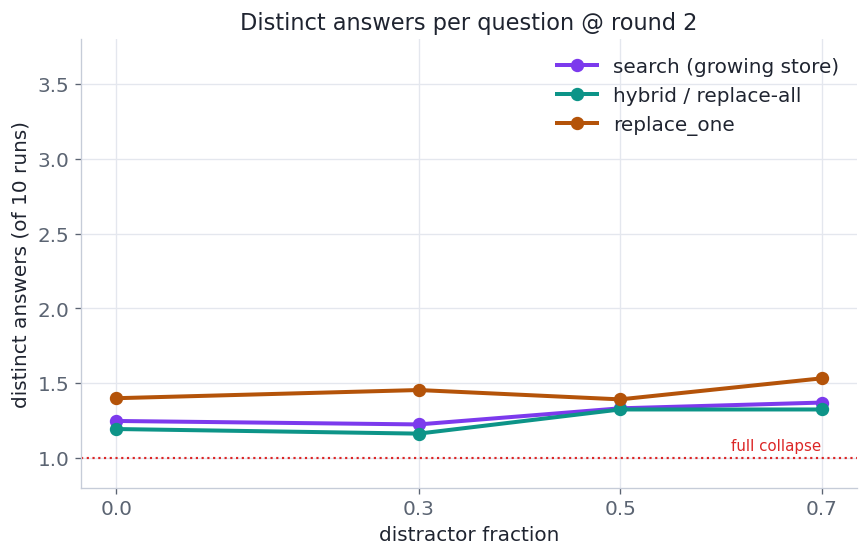

In [7]:
dose("distinct_answers", "Distinct answers per question @ round 2", "distinct answers (of 10 runs)", ref1=True, ymax=3.8, fname="conc_distinct.png")

## 6 · Example seeded distractors (qualitative)

In [8]:
bf = json.loads((DATA / "base_search_f0.7.json").read_text())
shown = 0
for q in bf["questions"]:
    dist = q.get("initial_distractor") or {}
    if not dist.get("eligible"):
        continue
    ents = [d["injected_entity"] for d in dist.get("distractors", []) if d.get("injected_entity")]
    answers = [(r.get("answer") or "").strip().replace("\n", " ")[:40] for r in q["iterations"][0]["runs"]]
    print("Q:", q["question_text"][:90])
    print("  gold:", dist.get("gold_answer"))
    print("  seeded distractors:", ", ".join(dict.fromkeys(ents)))
    print("  round-0 answers (10 runs):", answers); print()
    shown += 1
    if shown >= 3: break


Q: What government position was held by the woman who portrayed Corliss Archer in the film Ki
  gold: Chief of Protocol
  seeded distractors: United States Secretary of State, United States Secretary of Education, United States Senator, Governor of California, United States Attorney General, Member of the U.S. House of Representatives, White House Press Secretary
  round-0 answers (10 runs): ['White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary', 'White House Press Secretary']

Q: What science fantasy young adult series, told in first person, has a set of companion book
  gold: Animorphs
  seeded distractors: The Hunger Games, Divergent, Maximum Ride, Uglies, Shatter Me, Legend, Matched
  round-0 answers (10 runs): ['Legend', 'Legend', 'Legend', 'Legend Uglies The H